In [1]:
from time import time

import jax.numpy as jnp

from quantum_simulation.jpc_chip import JpcChip
from quantum_simulation.parameters_and_constants import JPCConfig, QuantumParameters

/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/qutip/settings.py:11: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/bradaizakaria/Document

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/ipykernel/ker

AttributeError: _ARRAY_API not found

In [12]:
import jax
# Cela va afficher la liste des processeurs détectés (ex: [CudaDevice(id=0)])
print("Appareils JAX détectés :", jax.devices())

Appareils JAX détectés : [CpuDevice(id=0)]


On pose $\hbar = 1$.

**Unités :** 
- Les fréquences et l'Hamiltonien sont données en $\mathrm{MHz}$
- Le temps est donné en  $\mu \mathrm{s} $
- Les $\epsilon$ sont donnés en $ \sqrt{\mathrm{MHz}} $

Dans le référentiel tournant (*Rotating Frame*) l'Hamiltonien du système s'écrit (sans drive) :

$$ H = K_{aa} \left(a^\dagger a \right)^2 + K_{bb} \left(b^\dagger b\right)^2 - K_{ab} \left(a^\dagger a\right) \left( b^\dagger b \right) + g \left( a^\dagger b + a b^\dagger \right) + g_\text{sq} \left( a^\dagger b^\dagger + a b \right) $$

Le *drive* s'exprime dans ce même référentiel :

$$ H_\text{drive} = \sqrt{\kappa_a}  \left( \epsilon_a^* a + \epsilon_a a^\dagger \right) + \sqrt{\kappa_b}  \left( \epsilon_b^* b + \epsilon_b b^\dagger \right)   $$

Le *collapse operator* s'exprime :

$$ C = \left[ \sqrt{\kappa_a}\; a \;, \;  \sqrt{\kappa_b}\; b \; , \; \sqrt{\kappa_\phi} \;\left( a^\dagger a + b^\dagger b \right) \right]$$


In [7]:
#X = jnp.array([-1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1, -1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1,
#              -1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1, -1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1 ])
#X = jnp.array([-1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1,
#               -1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1])
X = jnp.array([-1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7])


params_G = [QuantumParameters(
    g_conv=700,
    g_sq=20,
    epsilon_a=50,
    epsilon_b=50,
    delta_a=0,
    delta_b=0
)]

QP_Dudas = JPCConfig(
    DIM_A=15,
    DIM_B=15,
    OMEGA_A=1e4,
    OMEGA_B=9 * 1e3,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=100
)

QP = QP_Dudas

chip = JpcChip(QP)


In [8]:
t1 = time()
A = chip.run_simulation(X, params_G, encoding_observable='epsilon')
print(time() - t1)

#c-profile

|██████████| 100.0% ◆ elapsed 20.51s ◆ remaining 0.00ms  


21.21032691001892


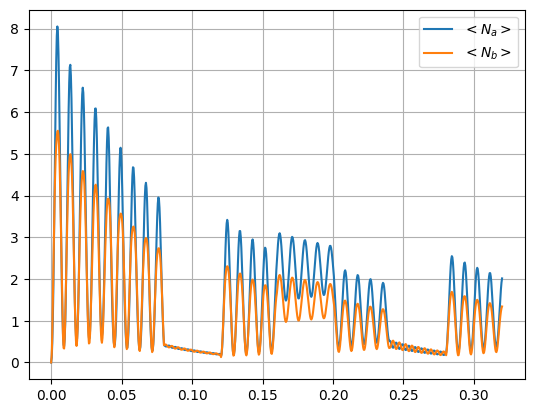

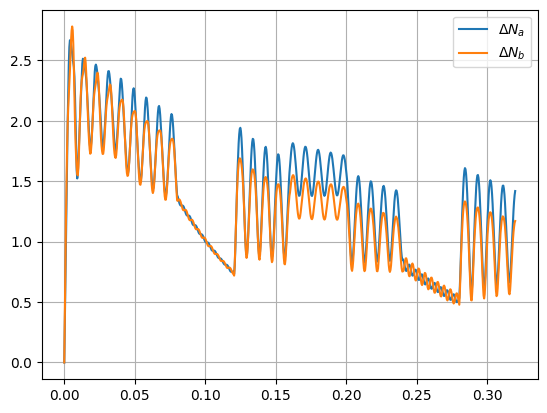

In [9]:
l = A[0].photon_distribution.Plot_Mean_Photon_Number()
l = A[0].photon_distribution.Plot_Sigma_Photon_Number()

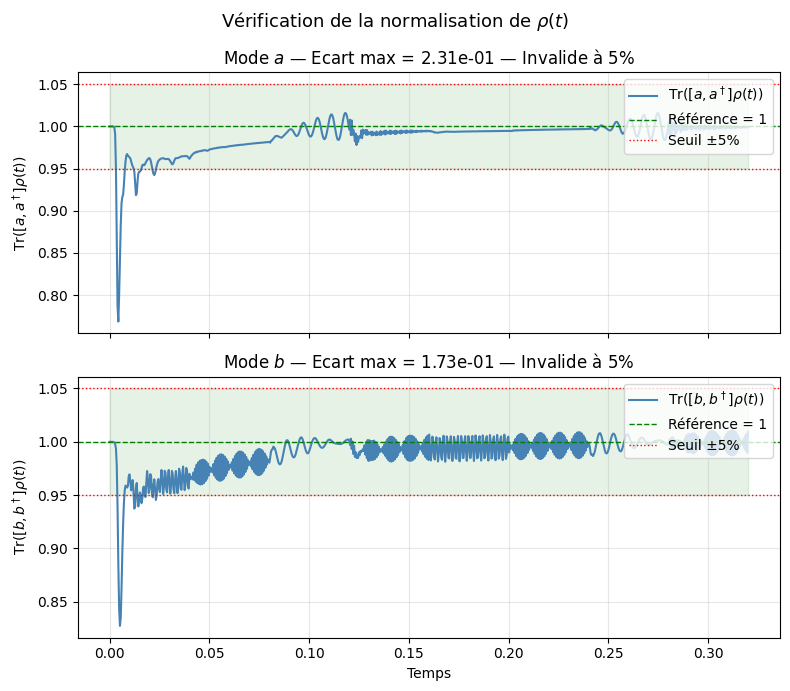

In [10]:
Tr_a, TR_b = A[0].plot_trace_verification()

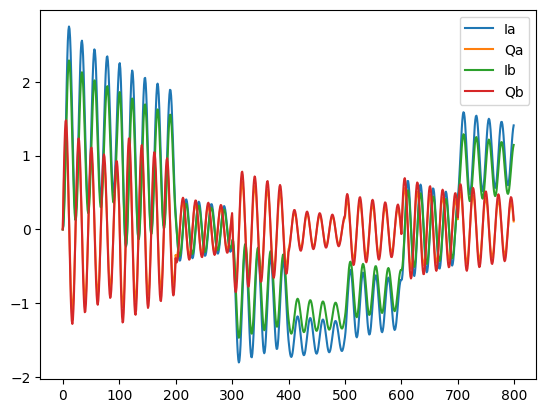

In [11]:
A[0].quadratures.plot()

In [7]:
import numpy as np
import sys

# Pour afficher TOUT le tableau sans troncature
np.set_printoptions(threshold=sys.maxsize)

# Pour afficher un nombre précis de chiffres après la virgule (ex: 4)
np.set_printoptions(precision=4, suppress=True)

print(A[0].quadratures.L_Ia.reshape(10, -1))

[[ 0.     -0.0179 -0.0711 -0.158  -0.2762 -0.4226 -0.5935 -0.7845 -0.9909
  -1.2074 -1.4285 -1.6479 -1.8589 -2.0542 -2.2273 -2.3747 -2.4937 -2.5848
  -2.6483 -2.6854 -2.6962 -2.6809 -2.6406 -2.5749 -2.4845 -2.3693 -2.2309
  -2.0714 -1.8955 -1.708  -1.5139 -1.3194 -1.1288 -0.9478 -0.7799 -0.6298
  -0.5003 -0.3946 -0.3151 -0.2628 -0.2396 -0.2446 -0.2786 -0.3392 -0.4255
  -0.5348 -0.6643 -0.8111 -0.9705 -1.1394 -1.312  -1.4849 -1.6525 -1.8112
  -1.9565 -2.0851 -2.1947 -2.283  -2.3499 -2.394  -2.416  -2.4143 -2.3899
  -2.3424 -2.2731 -2.1833 -2.0746 -1.95   -1.8117 -1.664  -1.5099 -1.3541
  -1.1999 -1.0516 -0.9125 -0.7859 -0.675  -0.5819 -0.5093 -0.4582]
 [-0.4303 -0.4255 -0.4441 -0.4854 -0.5481 -0.6306 -0.7305 -0.8454 -0.9723
  -1.1081 -1.2494 -1.3925 -1.5339 -1.67   -1.7975 -1.9133 -2.0145 -2.0991
  -2.1651 -2.2117 -2.2376 -2.2406 -2.2201 -2.1765 -2.1104 -2.0233 -1.9176
  -1.7958 -1.6613 -1.5173 -1.368  -1.2169 -1.0679 -0.9249 -0.7912 -0.6703
  -0.5648 -0.4776 -0.4103 -0.3649 -0.342  -0.

In [43]:
%matplotlib qt

In [57]:
A[0].photon_distribution.plot_joint_proba()

(<Figure size 1400x1200 with 3 Axes>,
 <matplotlib.widgets.Slider at 0x31fe7ef90>)

In [45]:
A[0].photon_distribution.plot_marginal_proba(mode='a')

(<Figure size 1400x800 with 2 Axes>,
 <matplotlib.widgets.Slider at 0x35a578b50>)

In [58]:
A[0].photon_distribution.plot_marginal_proba(mode='b')

(<Figure size 1400x800 with 2 Axes>,
 <matplotlib.widgets.Slider at 0x32fde3610>)

In [47]:
A[0].photon_distribution.P_b[-1]

Array([0.6785, 0.2132, 0.0719, 0.0232, 0.0072, 0.0025, 0.0011, 0.001 ,
       0.0005, 0.0007], dtype=float32)

In [51]:
import sympy as sp
from IPython.display import display, Math

# Variables
k1, k2 = sp.symbols('kappa1 kappa2', real=True)
g, gs = sp.symbols('g gs')

# Modules au carré
g2 = sp.Abs(g)**2
gs2 = sp.Abs(gs)**2

# Coefficients
p = g2 + gs2 + (k1**2 + k2**2)/4
q = (-g2 + gs2 - k1*k2/4)**2

# lambda^2
x_plus  = (-p + sp.sqrt(p**2 - 4*q)) / 2
x_minus = (-p - sp.sqrt(p**2 - 4*q)) / 2

# valeurs propres
lambdas = [
    sp.sqrt(x_plus), -sp.sqrt(x_plus),
    sp.sqrt(x_minus), -sp.sqrt(x_minus)
]

# Affichage LaTeX
for lam in lambdas:
    display(Math(sp.latex(sp.simplify(lam))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [49]:
eigs

{Piecewise((-kappa1/4 - kappa2/4 - sqrt(-2*delta1**2/3 - 2*delta2**2/3 - 4*g*conjugate(g)/3 + 4*gs*conjugate(gs)/3 - kappa1**2/6 - 2*kappa1*kappa2/3 - kappa2**2/6 + (kappa1 + kappa2)**2/4 - 2*(-(-delta1**2*kappa1/2 + delta1**2*kappa2/2 + delta2**2*kappa1/2 - delta2**2*kappa2/2)**2/8 - (delta1**2 + delta2**2 + 2*g*conjugate(g) - 2*gs*conjugate(gs) + kappa1**2/4 + kappa1*kappa2 + kappa2**2/4 - 3*(kappa1 + kappa2)**2/8)**3/108 + (delta1**2 + delta2**2 + 2*g*conjugate(g) - 2*gs*conjugate(gs) + kappa1**2/4 + kappa1*kappa2 + kappa2**2/4 - 3*(kappa1 + kappa2)**2/8)*(delta1**2*delta2**2 + delta1**2*kappa1**2/16 - delta1**2*kappa1*kappa2/8 + delta1**2*kappa2**2/16 - 2*delta1*delta2*g*conjugate(g) - 2*delta1*delta2*gs*conjugate(gs) + delta2**2*kappa1**2/16 - delta2**2*kappa1*kappa2/8 + delta2**2*kappa2**2/16 - g**2*gs*conjugate(gs) + g**2*conjugate(g)**2 - g*kappa1**2*conjugate(g)/8 + g*kappa1*kappa2*conjugate(g)/4 - g*kappa2**2*conjugate(g)/8 + gs**2*conjugate(gs)**2 + gs*kappa1**2*conjugate(gs

In [50]:
sp.latex(eigs)

'\\left\\{ \\begin{cases} - \\frac{\\kappa_{1}}{4} - \\frac{\\kappa_{2}}{4} - \\frac{\\sqrt{- \\frac{2 \\delta_{1}^{2}}{3} - \\frac{2 \\delta_{2}^{2}}{3} - \\frac{4 g \\overline{g}}{3} + \\frac{4 gs \\overline{gs}}{3} - \\frac{\\kappa_{1}^{2}}{6} - \\frac{2 \\kappa_{1} \\kappa_{2}}{3} - \\frac{\\kappa_{2}^{2}}{6} + \\frac{\\left(\\kappa_{1} + \\kappa_{2}\\right)^{2}}{4} - 2 \\sqrt[3]{- \\frac{\\left(- \\frac{\\delta_{1}^{2} \\kappa_{1}}{2} + \\frac{\\delta_{1}^{2} \\kappa_{2}}{2} + \\frac{\\delta_{2}^{2} \\kappa_{1}}{2} - \\frac{\\delta_{2}^{2} \\kappa_{2}}{2}\\right)^{2}}{8} - \\frac{\\left(\\delta_{1}^{2} + \\delta_{2}^{2} + 2 g \\overline{g} - 2 gs \\overline{gs} + \\frac{\\kappa_{1}^{2}}{4} + \\kappa_{1} \\kappa_{2} + \\frac{\\kappa_{2}^{2}}{4} - \\frac{3 \\left(\\kappa_{1} + \\kappa_{2}\\right)^{2}}{8}\\right)^{3}}{108} + \\frac{\\left(\\delta_{1}^{2} + \\delta_{2}^{2} + 2 g \\overline{g} - 2 gs \\overline{gs} + \\frac{\\kappa_{1}^{2}}{4} + \\kappa_{1} \\kappa_{2} + \\frac{\\kappa

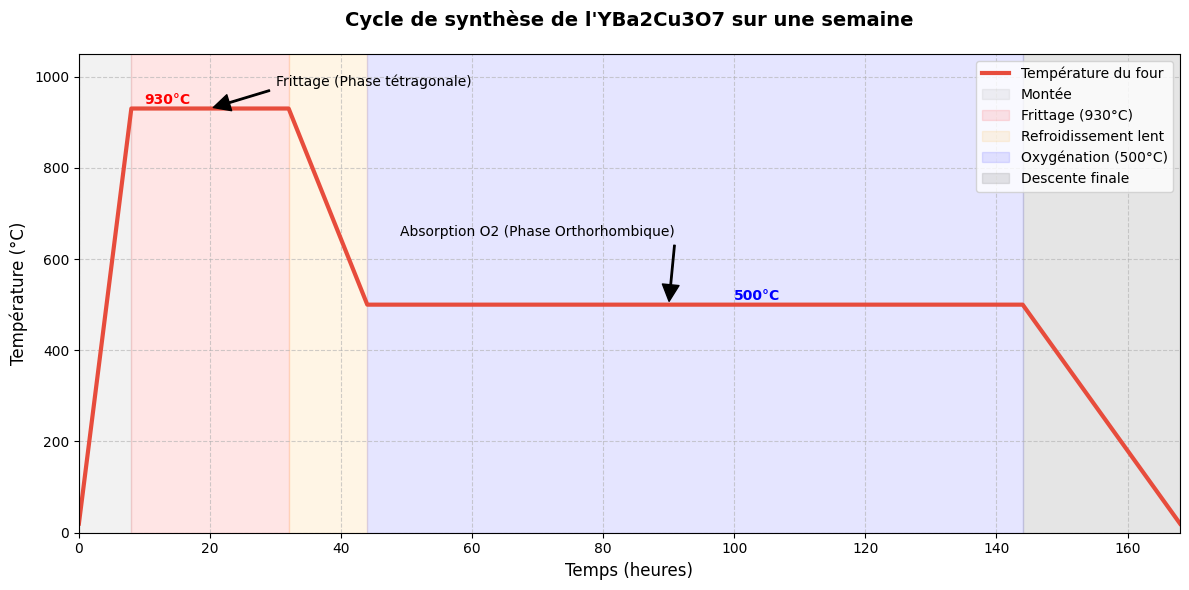

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Configuration des données du cycle (Temps en heures, Température en °C)
# 1 semaine = 168 heures
temps = [0, 8, 32, 44, 144, 168]
température = [20, 930, 930, 500, 500, 20]

# Création du graphique
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(temps, température, color='#e74c3c', linewidth=3, label="Température du four")

# Personnalisation des axes
plt.title("Cycle de synthèse de l'YBa2Cu3O7 sur une semaine", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Temps (heures)", fontsize=12)
plt.ylabel("Température (°C)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 168)
plt.ylim(0, 1050)

# Ajout des zones colorées pour les phases
plt.axvspan(0, 8, color='gray', alpha=0.1, label="Montée")
plt.axvspan(8, 32, color='red', alpha=0.1, label="Frittage (930°C)")
plt.axvspan(32, 44, color='orange', alpha=0.1, label="Refroidissement lent")
plt.axvspan(44, 144, color='blue', alpha=0.1, label="Oxygénation (500°C)")
plt.axvspan(144, 168, color='gray', alpha=0.2, label="Descente finale")

# Annotations pour les points clés
plt.annotate('Frittage (Phase tétragonale)', xy=(20, 930), xytext=(30, 980),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.annotate('Absorption O2 (Phase Orthorhombique)', xy=(90, 500), xytext=(70, 650),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1), ha='center')

# Affichage des valeurs sur les paliers
plt.text(10, 940, "930°C", fontweight='bold', color='red')
plt.text(100, 510, "500°C", fontweight='bold', color='blue')

# Légende et affichage
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()